In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df=pd.read_csv('F:\\PYTHON PROJ\\LEARN PYTHON\\Customer Churn Prediction\\churn_cleaned and reengi data.csv')

In [19]:
X = df.drop(['Churn'],axis=1)
y=df['Churn']

In [20]:
df.describe().loc[['mean','std','min','max']].T


,mean,std,min,max
gender,0.504756,0.500013,0.000,1.000
SeniorCitizen,0.162147,0.368612,0.000,1.000
Partner,0.483033,0.499748,0.000,1.000
Dependents,0.299588,0.458110,0.000,1.000
tenure,32.371149,24.559481,0.000,72.000
PhoneService,0.903166,0.295752,0.000,1.000
MultipleLines,0.421837,0.493888,0.000,1.000
OnlineSecurity,0.286668,0.452237,0.000,1.000
OnlineBackup,0.344881,0.475363,0.000,1.000
DeviceProtection,0.343888,0.475038,0.000,1.000


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state= 42, stratify=y)

In [22]:
X_A_train = X_train.loc[:, ~X.columns.str.contains('tenure_group')]
X_A_test = X_test.loc[:, ~X.columns.str.contains('tenure_group')]

X_B_train=X_train.drop(columns=['tenure'])
X_B_test=X_test.drop(columns=['tenure'])


X_C_train=X_train.copy()
X_C_test=X_test.copy()


In [23]:
X_C_train.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 5634 non-null   int64  
 1   SeniorCitizen                          5634 non-null   int64  
 2   Partner                                5634 non-null   int64  
 3   Dependents                             5634 non-null   int64  
 4   tenure                                 5634 non-null   int64  
 5   PhoneService                           5634 non-null   int64  
 6   MultipleLines                          5634 non-null   int64  
 7   OnlineSecurity                         5634 non-null   int64  
 8   OnlineBackup                           5634 non-null   int64  
 9   DeviceProtection                       5634 non-null   int64  
 10  TechSupport                            5634 non-null   int64  
 11  StreamingTV      

In [24]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics  import  recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score

def train_eval(X_train, X_test, y_train, y_test):
    xgb = XGBClassifier(n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8, 
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=11
    )
    xgb.fit(X_train, y_train)

    y_prob = xgb.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)

    return {
        "AUC": roc_auc_score(y_test, y_prob),
        "F1": f1_score(y_test, y_pred),
        "y_prob": y_prob,
        "y_pred": y_pred
    }, xgb

In [26]:
res_A, xgb_A = train_eval(X_A_train, X_A_test, y_train, y_test)
res_B, xgb_B = train_eval(X_B_train, X_B_test, y_train, y_test)
res_C, xgb_C = train_eval(X_C_train, X_C_test, y_train, y_test)

In [27]:
import pandas as pd

results = pd.DataFrame({
    "Model A (tenure)": res_A,
    "Model B (group)": res_B,
    "Model C (both)": res_C
}).T

print(results)

                       AUC        F1  \
Model A (tenure)  0.838206  0.624729   
Model B (group)   0.834148  0.622951   
Model C (both)    0.837263  0.617744   

                                                             y_prob  \
Model A (tenure)  [0.006599315, 0.94313526, 0.22908197, 0.561565...   
Model B (group)   [0.0064845667, 0.96274966, 0.3127878, 0.591304...   
Model C (both)    [0.009354781, 0.96540624, 0.32793948, 0.520572...   

                                                             y_pred  
Model A (tenure)  [0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, ...  
Model B (group)   [0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, ...  
Model C (both)    [0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, ...  


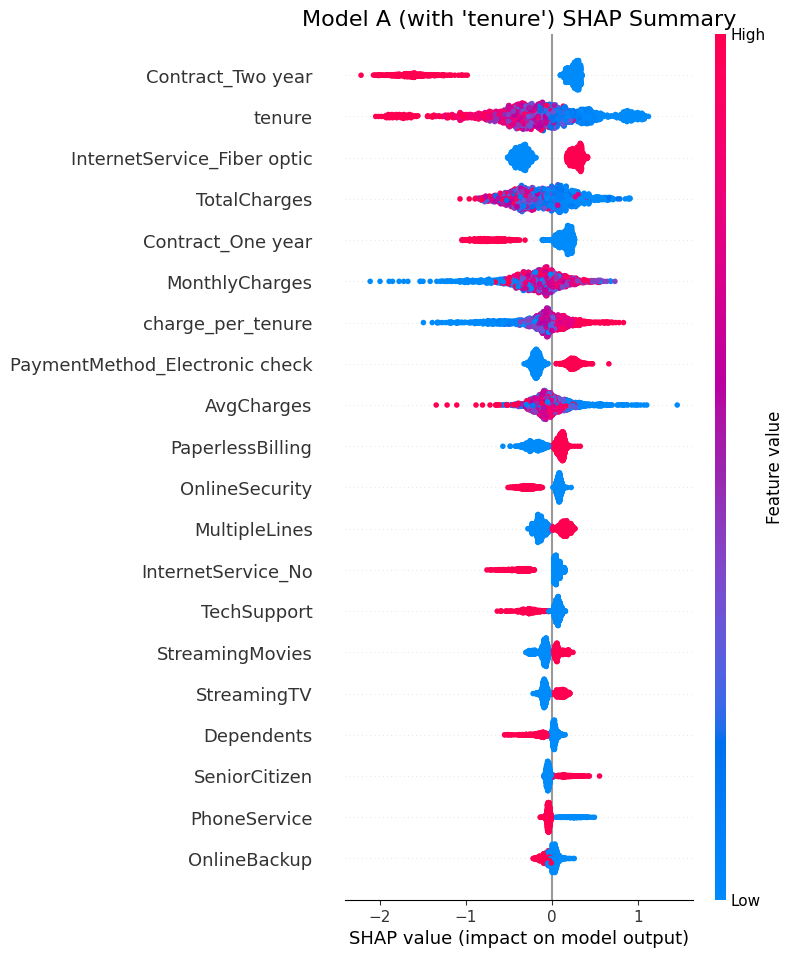

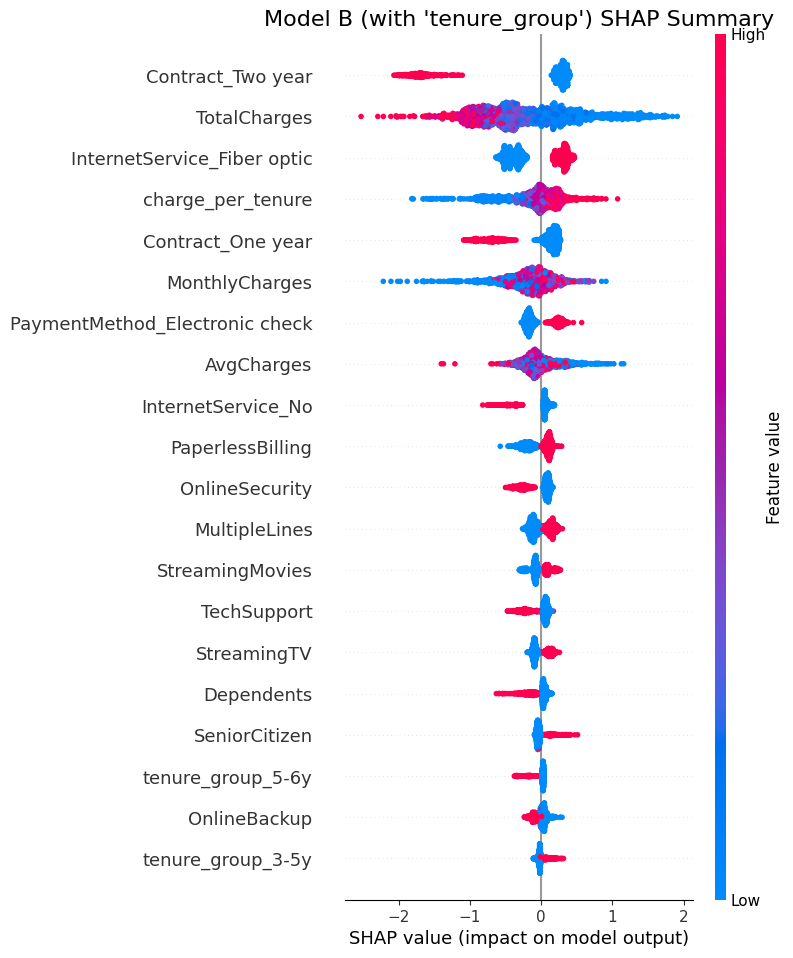

In [28]:

import shap
explainer_A=shap.TreeExplainer(xgb_A)
explainer_B = shap.TreeExplainer(xgb_B)
shap_values_A=explainer_A.shap_values(X_A_test)
shap_values_B = explainer_B.shap_values(X_B_test)


plt.figure(figsize=(8,6))
shap.summary_plot(
    shap_values_A,
    X_A_test,
    show=False
)
plt.title("Model A (with 'tenure') SHAP Summary", fontsize=16)

plt.savefig("shap_A.png")
plt.show()
#-----model b--------#
plt.figure(figsize=(8,6))
shap.summary_plot(
    shap_values_B, 
    X_B_test,
    show=False
)
plt.title("Model B (with 'tenure_group') SHAP Summary", fontsize=16)

plt.savefig("shap_B.png")
plt.show()
plt.close()



## Waterfall plot 

In [29]:
res_A['y_prob']

array([0.00659931, 0.94313526, 0.22908197, ..., 0.11484028, 0.2891198 ,
       0.0090411 ], shape=(1409,), dtype=float32)

In [30]:

high_risk_idx_A = res_A['y_prob'].argmax()
print(f"hihgh churn risk idex: {high_risk_idx_A}")
print(f"churn prob:   {res_A['y_prob'][high_risk_idx_A]:.3f}")
print(f"label:       {'Churn✓' if y_test.iloc[high_risk_idx_A]==1 else 'Not churn'}")

hihgh churn risk idex: 1109
churn prob:   0.979
label:       Churn✓


hihgh churn risk idex: 1109
churn prob: 0.979
label: Churn✓


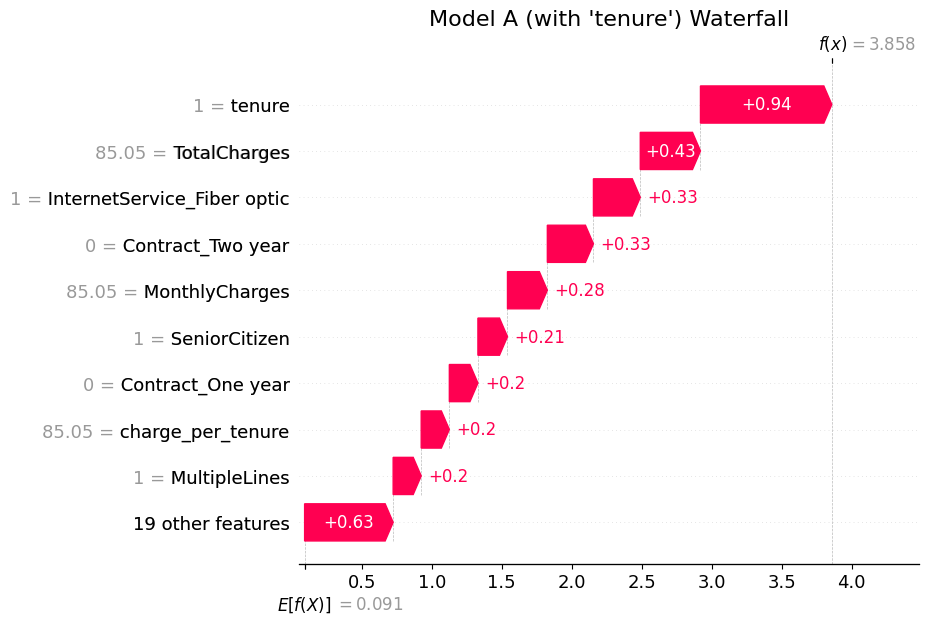

In [31]:

# Waterfall Plot

from os import close

from scipy.__config__ import show


high_risk_idx_A = res_A['y_prob'].argmax()
high_risk_idx_B = res_B['y_prob'].argmax()

print(f"hihgh churn risk idex: {high_risk_idx_A}")
print(f"churn prob: {res_A['y_prob'][high_risk_idx_A]:.3f}")
print(f"label: {'Churn✓' if y_test.iloc[high_risk_idx_A]==1 else 'Not churn'}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_A[high_risk_idx_A],
        base_values=explainer_A.expected_value,
        data=X_A_test.iloc[high_risk_idx_A,:],
        feature_names=X_A_test.columns.tolist()
    ),
    show= False
)
plt.title("Model A (with 'tenure') Waterfall", fontsize=16)

plt.savefig('waterfallA.png', dpi=150, bbox_inches='tight')
plt.show()

hihgh churn risk idex: 1090
churn prob: 0.979
label: Churn✓


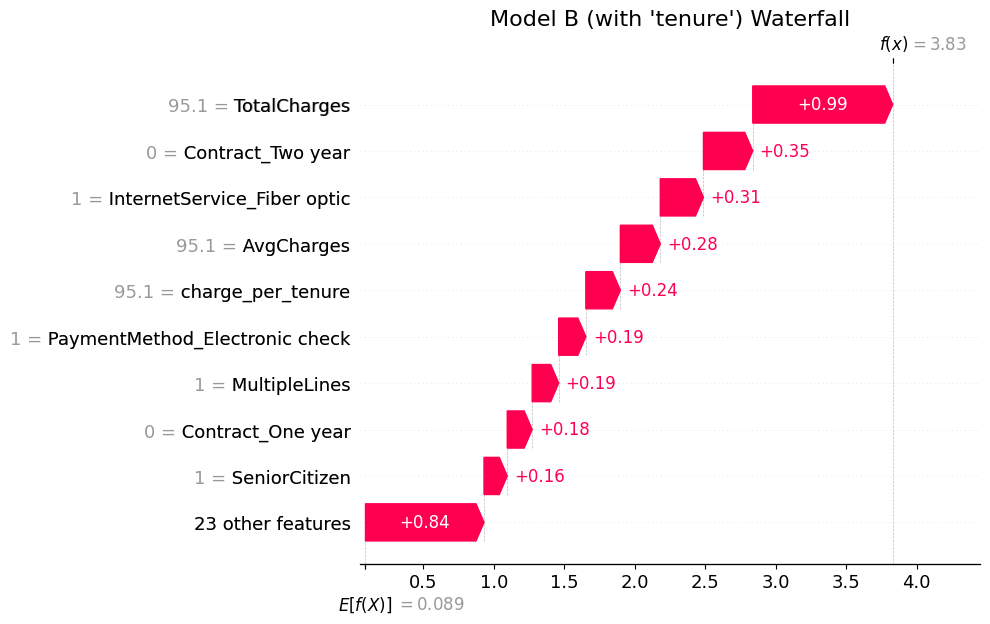

In [32]:
 

print(f"hihgh churn risk idex: {high_risk_idx_B}")
print(f"churn prob: {res_B['y_prob'][high_risk_idx_B]:.3f}")
print(f"label: {'Churn✓' if y_test.iloc[high_risk_idx_B]==1 else 'Not churn'}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_B[high_risk_idx_B],
        base_values=explainer_B.expected_value,
        data=X_B_test.iloc[high_risk_idx_B,:],
        feature_names=X_B_test.columns.tolist()
    ),
    show= False
)
plt.title("Model B (with 'tenure') Waterfall", fontsize=16)

plt.savefig('waterfallB.png', dpi=150, bbox_inches='tight')
plt.show()